In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py


In [6]:
mask.size

352

352
352


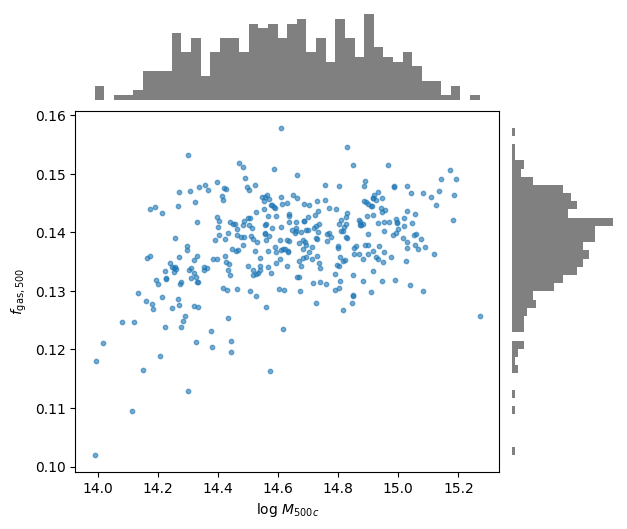

In [8]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec

with h5py.File('outputs/tng_cluster_catalog.hdf5', 'r') as f:
    x = f['table/mhalo_500c'][:]
    y = f['table/fgas_r500'][:]
print(y.size)
# filter out nonpositive x if log scale is used
mask = (x > 0) & (y > 0)
x, y = x[mask], y[mask]
print(y.size)

# --- Layout ---
fig = plt.figure(figsize=(7, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                       wspace=0.05, hspace=0.05)

# Main scatter plot
ax_scatter = fig.add_subplot(gs[1, 0])
ax_scatter.scatter(x, y, s=10, alpha=0.6)
ax_scatter.set_xlabel(r'log $M_{500c}$')
ax_scatter.set_ylabel(r'$f_{\mathrm{gas},500}$')

# Top histogram (marginal of x)
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_histx.hist(x, bins=40, color='gray')
ax_histx.axis('off')

# Right histogram (marginal of y)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatter)
ax_histy.hist(y, bins=40, orientation='horizontal', color='gray')
ax_histy.axis('off')

# optional limits
# ax_scatter.set_xlim(1e14, 1e15)
# ax_scatter.set_ylim(0.03, 0.18)

plt.show()
